# Weak GPU Complexity Benchmark: Mat32 / top_q / N

目标是稳定识别经验复杂度、定位瓶颈、比较算法在弱 GPU 上的拐点，不追求单点最快。

本 notebook 只回答四个问题：

- Q1: `gpu_v1_topq0` 的总时间随 `N` 如何增长。
- Q2: `gpu_v3_topq` 相比 `gpu_v1_topq0` 在不同 `N` 下更快还是更慢，拐点在哪里。
- Q3: 时间增长主要来自哪一段：`precompute/eigenspace/solve/predict`。
- Q4: 随着 `N` 增大，`top_q>0` 的优势是在扩大还是缩小。

实验拆成三层：

1. 端到端时间 vs `N`
2. 分阶段时间 vs `N`
3. 迭代统计 vs `N`

控制变量固定：

- 数据分布固定（2D + Mat32 + 固定采样分布）
- `eps` 固定
- `cg_tol` 固定
- `N_test` 固定
- 每条曲线内部 `top_q` 固定

输出要求：

- 每次 run 结果会 `print`
- 同时保存 `raw csv`
- 聚合统计保存 `summary csv`
- 图像保存到 `png`


In [9]:
'''
from google.colab import drive
import os

# 挂载 Google Drive
drive.mount('/content/drive')

# 定义一个方便引用的实验结果保存路径（建议根据项目命名）
# 这会在你的 Google Drive 根目录下创建一个文件夹
DRIVE_OUTPUT_DIR = '/content/drive/MyDrive/Colab_Experiments/EFGP_Eigenpro'

if not os.path.exists(DRIVE_OUTPUT_DIR):
    os.makedirs(DRIVE_OUTPUT_DIR)
    print(f"✅ 已在 Drive 中创建目录: {DRIVE_OUTPUT_DIR}")
else:
    print(f"📂 实验结果将同步至: {DRIVE_OUTPUT_DIR}")
'''

'\nfrom google.colab import drive\nimport os\n\n# 挂载 Google Drive\ndrive.mount(\'/content/drive\')\n\n# 定义一个方便引用的实验结果保存路径（建议根据项目命名）\n# 这会在你的 Google Drive 根目录下创建一个文件夹\nDRIVE_OUTPUT_DIR = \'/content/drive/MyDrive/Colab_Experiments/EFGP_Eigenpro\'\n\nif not os.path.exists(DRIVE_OUTPUT_DIR):\n    os.makedirs(DRIVE_OUTPUT_DIR)\n    print(f"✅ 已在 Drive 中创建目录: {DRIVE_OUTPUT_DIR}")\nelse:\n    print(f"📂 实验结果将同步至: {DRIVE_OUTPUT_DIR}")\n'

In [10]:
## For github import
'''
import os
import sys

GITHUB_USER = "Yifiwifi"
REPO_NAME = "EFGP-Eigenpro"
SUB_DIR = "efgp_eigenpro_py"
PROJECT_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(PROJECT_PATH):
    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git
else:
    %cd {PROJECT_PATH}
    !git pull origin main

CODE_ROOT = os.path.join(PROJECT_PATH, SUB_DIR)
if CODE_ROOT not in sys.path:
    sys.path.append(CODE_ROOT)

print("Checking runtime dependencies")
!pip install cufinufft cupy-cuda12x --extra-index-url https://pypi.nvidia.com

requirements_path = os.path.join(CODE_ROOT, "requirements.txt")
if os.path.exists(requirements_path):
    !pip install -r {requirements_path}

sanity_check_path = os.path.join(CODE_ROOT, "gpu/sanity_check")
if os.path.exists(sanity_check_path):
    os.chdir(sanity_check_path)
    print("cwd:", os.getcwd())
else:
    print("sanity_check path not found:", sanity_check_path)

# Refresh runtime library path for some Colab images
os.environ["LD_LIBRARY_PATH"] = "/usr/local/lib:" + os.environ.get("LD_LIBRARY_PATH", "")
!ldconfig /usr/local/lib

print("=" * 40)
try:
    import torch
    import cupy as cp
    import cufinufft
    cp.cuda.Stream.null.synchronize()
    print("PyTorch:", torch.__version__)
    print("GPU:", torch.cuda.get_device_name(0))
    print("cufinufft import ok")
except Exception as e:
    print("runtime check failed:", e)
print("=" * 40)
'''


'\nimport os\nimport sys\n\nGITHUB_USER = "Yifiwifi"\nREPO_NAME = "EFGP-Eigenpro"\nSUB_DIR = "efgp_eigenpro_py"\nPROJECT_PATH = f"/content/{REPO_NAME}"\n\nif not os.path.exists(PROJECT_PATH):\n    !git clone https://github.com/{GITHUB_USER}/{REPO_NAME}.git\nelse:\n    %cd {PROJECT_PATH}\n    !git pull origin main\n\nCODE_ROOT = os.path.join(PROJECT_PATH, SUB_DIR)\nif CODE_ROOT not in sys.path:\n    sys.path.append(CODE_ROOT)\n\nprint("Checking runtime dependencies")\n!pip install cufinufft cupy-cuda12x --extra-index-url https://pypi.nvidia.com\n\nrequirements_path = os.path.join(CODE_ROOT, "requirements.txt")\nif os.path.exists(requirements_path):\n    !pip install -r {requirements_path}\n\nsanity_check_path = os.path.join(CODE_ROOT, "gpu/sanity_check")\nif os.path.exists(sanity_check_path):\n    os.chdir(sanity_check_path)\n    print("cwd:", os.getcwd())\nelse:\n    print("sanity_check path not found:", sanity_check_path)\n\n# Refresh runtime library path for some Colab images\nos.env

In [11]:
import time
from datetime import timedelta
start_time = time.time()

In [12]:
import gc
import os
import sys
import time
import json
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
_candidates = [
    _here,
    _here.parent,
    _here.parent.parent,
    _here.parent.parent.parent,
    Path("D:/NU/ML"),
]
for p in _candidates:
    pkg_dir = p / "efgp_eigenpro_py"
    if pkg_dir.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))
        break

from efgp_eigenpro_py.kernels import make_matern
from efgp_eigenpro_py.efgp_solver import EFGPSolver
from efgp_eigenpro_py.benchmark import make_dataset, make_test_set, true_func_2d, compute_rmse
from efgp_eigenpro_py.gpu.backends import BackendConfig
from efgp_eigenpro_py.gpu.versions import GPURunConfig, run_v1_pure_efgp, run_v3_full_gpu_eigenspace
from efgp_eigenpro_py.gpu.v3_eigenspace import EigenspaceConfig

try:
    import cupy as cp
except Exception:
    cp = None

np.set_printoptions(precision=6, suppress=True)
print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])
print("cupy available:", cp is not None)


cwd: d:\NU\ML\efgp_eigenpro_py\gpu\sanity_check
sys.path[0]: D:\NU\ML
cupy available: True


In [13]:
# ---- Fixed controls ----
DIM = 2
LENGTHSCALE = 0.1
NU = 1.5
REG_LAMBDA = 0.1
EPS = 1e-6
SOLVE_TOL = 1e-6
GPU_MAXITER = 3000
GPU_NUFFT = "auto"
L2_SCALED = True

N_TEST = 1000
NOISE = 0.02
SEED_TRAIN_BASE = 20260421
SEED_TEST = 1

# Recommended weak-GPU first round
N_LIST = [100_000, 300_000]                    # [100_000, 300_000, 1_000_000, 3_000_000, 10_000_000]
MODE_SPECS = [
    {"mode": "gpu_v1_topq0", "top_q": 0},
    {"mode": "gpu_v3_topq", "top_q": 64},
    {"mode": "gpu_v3_topq_cupy_eigsh", "top_q": 64},
    {"mode": "gpu_v3_topq_rand_subspace_rr", "top_q": 64},
    {"mode": "gpu_v3_topq_eigenpro_nystrom", "top_q": 64},
]

REPEATS_POLICY = {
    "small": 5,   # N <= 1e6
    "mid": 5,     # N == 3e6
    "large": 5,    # N >= 1e7
}

WARMUP_N = 100_000
WARMUP_SEED = 7
CLEAR_POOL_PER_N = True

V3_OVERSAMPLE = 16
V3_N_ITER = 3

# EigenPro Nyström：与 v1_mat32_eps_topq_eigenspace_compare.ipynb 中 EIGENPRO_NYSTROM_* 一致
EIGENPRO_NYSTROM_PRECOND_KIND = "coordinate_nystrom"
EIGENPRO_NYSTROM_SURROGATE_SIZE = 1600  # ~10 * (top_q+1) when top_q=64；设为 None 则 10 * (top_q + 1)
EIGENPRO_NYSTROM_LOWFREQ_RATIO = 0.25
EIGENPRO_NYSTROM_OVERSAMPLE = 10
EIGENPRO_NYSTROM_RITZ_REFINE = False
EIGENPRO_NYSTROM_SEED = 0
EIGENPRO_NYSTROM_BLOCK_ROWS = 8192  # None => auto（见 v3 _auto_block_rows）
EIGENPRO_NYSTROM_RITZ_BLOCK_COLS = 16
EIGENPRO_NYSTROM_LIFT = False  # False：仅 I[:,S]V，不做 K[:,S]T^-1 全网格 lift（与 v1 注释一致）


def make_eigenpro_nystrom_eigenspace_config(top_q: int) -> EigenspaceConfig:
    """主流程 `gpu_v3_topq_eigenpro_nystrom` 的 EigenPro–Nyström 子空间配置（与 v1 一致，不经 SLQ）。"""
    tq = int(top_q)
    if EIGENPRO_NYSTROM_SURROGATE_SIZE is not None:
        s_nys = int(EIGENPRO_NYSTROM_SURROGATE_SIZE)
    else:
        s_nys = 10 * (tq + 1)
    br = EIGENPRO_NYSTROM_BLOCK_ROWS
    return EigenspaceConfig(
        q_max=tq,
        block_size=max(s_nys, tq + 1),
        n_iter=0,
        eig_method="eigenpro_nystrom",
        method_cfg={"precond_kind": str(EIGENPRO_NYSTROM_PRECOND_KIND).lower()},
        surrogate_size=s_nys,
        surrogate_oversample=int(EIGENPRO_NYSTROM_OVERSAMPLE),
        surrogate_lowfreq_ratio=float(EIGENPRO_NYSTROM_LOWFREQ_RATIO),
        surrogate_ritz_refine=bool(EIGENPRO_NYSTROM_RITZ_REFINE),
        surrogate_seed=int(EIGENPRO_NYSTROM_SEED),
        surrogate_block_rows=None if br is None else int(br),
        surrogate_ritz_block_cols=int(EIGENPRO_NYSTROM_RITZ_BLOCK_COLS),
        surrogate_lift=bool(EIGENPRO_NYSTROM_LIFT),
    )

RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("outputs") / f"weak_gpu_complexity_{RUN_TAG}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_CSV = OUT_DIR / "raw_runs.csv"
SUMMARY_CSV = OUT_DIR / "summary_by_mode_n.csv"
ENV_JSON = OUT_DIR / "env_info.json"

print("RUN_TAG:", RUN_TAG)
print("OUT_DIR:", OUT_DIR)
print("N_LIST:", N_LIST)
print("MODE_SPECS:", MODE_SPECS)
print(
    "EIGENPRO_NYSTROM:",
    f"precond={EIGENPRO_NYSTROM_PRECOND_KIND}, surrogate_size={EIGENPRO_NYSTROM_SURROGATE_SIZE}, "
    f"lowfreq_ratio={EIGENPRO_NYSTROM_LOWFREQ_RATIO}, oversample={EIGENPRO_NYSTROM_OVERSAMPLE}, "
    f"ritz_refine={EIGENPRO_NYSTROM_RITZ_REFINE}, seed={EIGENPRO_NYSTROM_SEED}, "
    f"block_rows={EIGENPRO_NYSTROM_BLOCK_ROWS}, ritz_block_cols={EIGENPRO_NYSTROM_RITZ_BLOCK_COLS}, "
    f"lift={EIGENPRO_NYSTROM_LIFT}",
)


RUN_TAG: 20260427_010610
OUT_DIR: outputs\weak_gpu_complexity_20260427_010610
N_LIST: [100000, 300000]
MODE_SPECS: [{'mode': 'gpu_v1_topq0', 'top_q': 0}, {'mode': 'gpu_v3_topq', 'top_q': 64}, {'mode': 'gpu_v3_topq_cupy_eigsh', 'top_q': 64}, {'mode': 'gpu_v3_topq_rand_subspace_rr', 'top_q': 64}, {'mode': 'gpu_v3_topq_eigenpro_nystrom', 'top_q': 64}]
EIGENPRO_NYSTROM: precond=coordinate_nystrom, surrogate_size=1600, lowfreq_ratio=0.25, oversample=10, ritz_refine=False, seed=0, block_rows=8192, ritz_block_cols=16, lift=False


In [14]:
kernel = make_matern(lengthscale=LENGTHSCALE, nu=NU, dim=DIM, variance=1.0)
x_test, y_test = make_test_set(DIM, N_TEST, true_func_2d, seed=SEED_TEST)


def _sync_gpu():
    if cp is not None:
        cp.cuda.Stream.null.synchronize()


def _clear_state(clear_pool=False):
    _sync_gpu()
    gc.collect()
    if cp is not None and clear_pool:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    _sync_gpu()


def _gpu_mem_used_gb():
    if cp is None:
        return np.nan
    try:
        free_b, total_b = cp.cuda.runtime.memGetInfo()
        return float((total_b - free_b) / (1024 ** 3))
    except Exception:
        return np.nan


def _device_name():
    if cp is None:
        return "cpu"
    try:
        return cp.cuda.runtime.getDeviceProperties(0)["name"].decode("utf-8")
    except Exception:
        return "unknown_gpu"


def _pick_repeats(n_train: int) -> int:
    if n_train <= 1_000_000:
        return int(REPEATS_POLICY["small"])
    if n_train >= 10_000_000:
        return int(REPEATS_POLICY["large"])
    return int(REPEATS_POLICY["mid"])


def _collect_env_info():
    info = {
        "timestamp": datetime.now().isoformat(),
        "python": sys.version,
        "platform": sys.platform,
        "device_name": _device_name(),
        "eps": EPS,
        "solve_tol": SOLVE_TOL,
        "gpu_maxiter": GPU_MAXITER,
        "nufft_mode": GPU_NUFFT,
        "l2_scaled": L2_SCALED,
        "dim": DIM,
        "kernel": "Mat32",
        "nu": NU,
        "lengthscale": LENGTHSCALE,
        "reg_lambda": REG_LAMBDA,
        "n_test": N_TEST,
        "n_list": [int(v) for v in N_LIST],
        "mode_specs": MODE_SPECS,
        "eigenpro_nystrom": {
            "precond_kind": EIGENPRO_NYSTROM_PRECOND_KIND,
            "surrogate_size": EIGENPRO_NYSTROM_SURROGATE_SIZE,
            "lowfreq_ratio": EIGENPRO_NYSTROM_LOWFREQ_RATIO,
            "oversample": EIGENPRO_NYSTROM_OVERSAMPLE,
            "ritz_refine": EIGENPRO_NYSTROM_RITZ_REFINE,
            "seed": EIGENPRO_NYSTROM_SEED,
            "block_rows": EIGENPRO_NYSTROM_BLOCK_ROWS,
            "ritz_block_cols": EIGENPRO_NYSTROM_RITZ_BLOCK_COLS,
            "lift": EIGENPRO_NYSTROM_LIFT,
        },
    }
    try:
        import cupy
        info["cupy"] = cupy.__version__
    except Exception:
        info["cupy"] = "unavailable"
    try:
        import cufinufft
        info["cufinufft"] = getattr(cufinufft, "__version__", "unknown")
    except Exception:
        info["cufinufft"] = "unavailable"
    return info


def _extract_common_metrics(diag: dict):
    return {
        "cg_iters": int(diag.get("cg_iters", -1)),
        "cg_relres": float(diag.get("cg_relres", np.nan)),
        "n_matvec": int(diag.get("n_matvec", 0)),
        "t_matvec_total": float(diag.get("t_matvec_total", np.nan)),
        "n_precond": int(diag.get("n_precond", 0)),
        "t_precond_total": float(diag.get("t_precond_total", np.nan)),
        "time_precompute": float(diag.get("time_precompute", np.nan)),
        "time_eigenspace": float(diag.get("time_eigenspace", 0.0)),
        "time_precond_build": float(diag.get("time_precond_build", 0.0)),
        "time_solve": float(diag.get("time_solve", np.nan)),
        "time_predict": float(diag.get("time_predict", np.nan)),
        "nufft_stage": str(diag.get("nufft_stage", "")),
        "device_name": str(diag.get("device_name", "")),
        "eig_nystrom_kernel_s": float(diag.get("eig_nystrom_kernel_s", np.nan)),
        "surrogate_tag": str(diag.get("surrogate_tag", "")),
    }


def _run_case_once(mode: str, top_q: int, n_train: int, seed_train: int, warmup_only=False) -> dict:
    x_train, y_train = make_dataset(DIM, n_train, true_func_2d, noise=NOISE, seed=seed_train)

    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    _sync_gpu()
    mem_before = _gpu_mem_used_gb()
    t0 = time.perf_counter()
    if mode == "gpu_v1_topq0":
        out = run_v1_pure_efgp(solver, x_train, y_train, cfg)
    elif mode == "gpu_v3_topq":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    else:
        raise ValueError(f"unsupported mode: {mode}")
    _sync_gpu()
    t1 = time.perf_counter()
    mem_after = _gpu_mem_used_gb()

    if warmup_only:
        return {"status": "warmup_done"}

    state_cpu = solver.precompute(x_train, y_train)
    if cp is None:
        beta_cpu = np.asarray(out.beta_gpu)
    else:
        beta_cpu = cp.asnumpy(out.beta_gpu)
    yhat = solver.predict(x_test, beta_cpu, state_cpu)
    rmse = float(compute_rmse(yhat, y_test))

    diag = out.diagnostics
    row = {
        "run_id": f"{RUN_TAG}_{mode}_q{int(top_q)}_N{int(n_train)}_{seed_train}",
        "timestamp": datetime.now().isoformat(),
        "mode": mode,
        "N": int(n_train),
        "eps": float(EPS),
        "top_q": int(top_q),
        "reg_lambda": float(REG_LAMBDA),
        "cg_tol": float(SOLVE_TOL),
        "wall_s_total": float(t1 - t0),
        "rmse_test": float(rmse),
        "peak_mem_gb": float(np.nanmax([mem_before, mem_after])),
        "status": "ok",
        "error": "",
    }
    row.update(_extract_common_metrics(diag))
    return row


def _run_warmup_for_mode(mode: str, top_q: int, n_ref: int):
    n_warm = int(min(n_ref, WARMUP_N))
    print(f"warmup start: mode={mode}, top_q={top_q}, N={n_warm}")
    _clear_state(clear_pool=False)
    _ = _run_case_once(mode=mode, top_q=top_q, n_train=n_warm, seed_train=WARMUP_SEED, warmup_only=True)
    _clear_state(clear_pool=False)
    print(f"warmup done: mode={mode}, top_q={top_q}")


env_info = _collect_env_info()
ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("env info saved:", ENV_JSON)
print(json.dumps(env_info, indent=2))


env info saved: outputs\weak_gpu_complexity_20260427_010610\env_info.json
{
  "timestamp": "2026-04-27T01:06:10.145926",
  "python": "3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]",
  "platform": "win32",
  "device_name": "NVIDIA GeForce RTX 3050 Laptop GPU",
  "eps": 1e-06,
  "solve_tol": 1e-06,
  "gpu_maxiter": 3000,
  "nufft_mode": "auto",
  "l2_scaled": true,
  "dim": 2,
  "kernel": "Mat32",
  "nu": 1.5,
  "lengthscale": 0.1,
  "reg_lambda": 0.1,
  "n_test": 1000,
  "n_list": [
    100000,
    300000
  ],
  "mode_specs": [
    {
      "mode": "gpu_v1_topq0",
      "top_q": 0
    },
    {
      "mode": "gpu_v3_topq",
      "top_q": 64
    },
    {
      "mode": "gpu_v3_topq_cupy_eigsh",
      "top_q": 64
    },
    {
      "mode": "gpu_v3_topq_rand_subspace_rr",
      "top_q": 64
    },
    {
      "mode": "gpu_v3_topq_eigenpro_nystrom",
      "top_q": 64
    }
  ],
  "eigenpro_nystrom": {
    "precond_kind": "coordinate_nystrom",
    "

In [15]:
# --- Add combo experiments (from v1 COMBO_GRID_VALUES) ---
from types import SimpleNamespace

from efgp_eigenpro_py.discretization import GridSpec
from efgp_eigenpro_py.gpu import surrogate_ops as sur_ops
from efgp_eigenpro_py.gpu.backends import build_gpu_backend_bundle
from efgp_eigenpro_py.gpu.contexts import ensure_gpu_data_context, GPUOperatorContext
from efgp_eigenpro_py.gpu.v1_ops import apply_A_v1, predict_v1
from efgp_eigenpro_py.gpu.v2_preconditioner import GPUPreconditionerData, apply_preconditioner_v2
from efgp_eigenpro_py.gpu.iterative_solvers import pcg_solve_gpu

COMBO_CFG_V1 = {
    "name": "combo_g0p1_e100_s0p3",
    "kind": "combo",
    "grid_scale": 0.1,
    "grid_m": None,
    "eps_factor": 100.0,
    "subsample_frac": 0.3,
    "subsample_seed": 0,
    "sur_iter": 1,
    "refine_iter": 1,
    "oversample": V3_OVERSAMPLE,
    "block_size": None,
}

_combo_specs = [
    {"mode": "gpu_v3_topq_combo", "top_q": 32, "combo_cfg": COMBO_CFG_V1},
    {"mode": "gpu_v3_topq_combo", "top_q": 64, "combo_cfg": COMBO_CFG_V1},
]
_existing = {(str(s.get("mode", "")), int(s.get("top_q", -1))) for s in MODE_SPECS}
for spec in _combo_specs:
    k = (spec["mode"], int(spec["top_q"]))
    if k not in _existing:
        MODE_SPECS.append(spec)


def _build_surrogate_grid(fine_m: int, fine_h: float, grid_scale=None, grid_m=None) -> GridSpec:
    if grid_m is not None:
        m_coarse = int(grid_m)
    else:
        scale = 1.0 if grid_scale is None else float(grid_scale)
        m_coarse = max(1, int(fine_m * scale))
    xis = np.arange(-m_coarse, m_coarse + 1) * float(fine_h)
    return GridSpec(xis=xis, h=float(fine_h), mtot=xis.size, hm=m_coarse)


def _embed_coarse_to_fine(xp, vecs_coarse, coarse_m: int, fine_m: int, dim: int = 2):
    if coarse_m == fine_m:
        return xp.asarray(vecs_coarse)
    cols = []
    for j in range(vecs_coarse.shape[1]):
        v = xp.asarray(vecs_coarse[:, j]).reshape((2 * coarse_m + 1,) * dim)
        vf = xp.zeros((2 * fine_m + 1,) * dim, dtype=v.dtype)
        s = fine_m - coarse_m
        e = s + (2 * coarse_m + 1)
        if dim == 2:
            vf[s:e, s:e] = v
        else:
            vf[(slice(s, e),) * dim] = v
        cols.append(vf.reshape(-1))
    return xp.stack(cols, axis=1)


def _run_v3_combo_case(solver, cfg, x_train, y_train, top_q: int, combo_cfg: dict):
    backend = build_gpu_backend_bundle(cfg.backend)
    xp = backend.xp
    q_max = int(top_q)

    data_ctx = ensure_gpu_data_context(backend, x_train, y_train, state=None)
    data_ctx.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx = GPUOperatorContext()

    t0 = time.perf_counter()
    data_ctx = sur_ops.gpu_precompute_v1(
        backend,
        solver.kernel,
        solver.eps,
        solver.nufft_tol,
        data_ctx,
        op_ctx,
        l2scaled=solver.l2scaled,
        chunk_size=cfg.chunk_size,
    )
    t1 = time.perf_counter()

    def _apply_block(local_ctx, local_op_ctx):
        def _fn(V):
            V = xp.asarray(V, dtype=xp.complex128)
            if V.ndim == 1:
                V = V.reshape(-1, 1)
            out = xp.empty_like(V)
            for i in range(V.shape[1]):
                apply_A_v1(
                    backend,
                    local_ctx,
                    V[:, i],
                    float(cfg.reg_lambda),
                    local_op_ctx,
                    out=out[:, i],
                )
            return out
        return _fn

    apply_A_fine = _apply_block(data_ctx, op_ctx)

    fine_mtot = int(data_ctx.meta.get("mtot", 0))
    fine_m = max(1, (fine_mtot - 1) // 2)
    fine_h = float(data_ctx.meta.get("h", 1.0))

    frac = float(combo_cfg.get("subsample_frac", 1.0))
    frac = min(max(frac, 1e-6), 1.0)
    n_sub = max(q_max + 2, int(len(x_train) * frac))
    n_sub = min(n_sub, len(x_train))
    seed = int(combo_cfg.get("subsample_seed", 0))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(x_train), size=n_sub, replace=False)
    x_use = np.asarray(x_train[idx])
    y_use = np.asarray(y_train[idx])

    eps_factor = float(combo_cfg.get("eps_factor", 1.0))
    eps_sur = float(solver.eps) * eps_factor

    grid_override = _build_surrogate_grid(
        fine_m,
        fine_h,
        grid_scale=combo_cfg.get("grid_scale", 1.0),
        grid_m=combo_cfg.get("grid_m", None),
    )

    data_ctx_sur = ensure_gpu_data_context(backend, x_use, y_use, state=None)
    data_ctx_sur.meta["debug_finite_checks"] = bool(cfg.debug_finite_checks)
    op_ctx_sur = GPUOperatorContext()

    t_sur_pre0 = time.perf_counter()
    data_ctx_sur = sur_ops.gpu_precompute_v1(
        backend,
        solver.kernel,
        eps_sur,
        solver.nufft_tol,
        data_ctx_sur,
        op_ctx_sur,
        l2scaled=solver.l2scaled,
        chunk_size=cfg.chunk_size,
        grid_override=grid_override,
    )
    t_sur_pre1 = time.perf_counter()

    size_sur = int(data_ctx_sur.rhs_gpu.size)
    if size_sur <= q_max:
        raise ValueError(f"surrogate size ({size_sur}) must be > top_q ({q_max})")

    sur_oversample = int(combo_cfg.get("oversample", V3_OVERSAMPLE))
    sur_block = combo_cfg.get("block_size")
    sur_block = int(q_max + sur_oversample) if sur_block is None else int(sur_block)
    sur_block = min(sur_block, size_sur)
    if sur_block <= q_max:
        sur_block = q_max + 1

    apply_A_sur = _apply_block(data_ctx_sur, op_ctx_sur)
    eig_cfg_sur = sur_ops.EigenspaceConfig(
        q_max=q_max,
        block_size=sur_block,
        n_iter=int(combo_cfg.get("sur_iter", 1)),
    )
    vals_sur, vecs_sur, _ = sur_ops.estimate_top_eigenspace_v3(
        backend=backend,
        apply_A_block_gpu=apply_A_sur,
        size=size_sur,
        cfg=eig_cfg_sur,
    )

    init_Q = vecs_sur
    init_Q = _embed_coarse_to_fine(xp, vecs_sur, int(grid_override.hm), fine_m, dim=DIM)

    eig_cfg_fine = sur_ops.EigenspaceConfig(
        q_max=q_max,
        block_size=max(sur_block, q_max + 1),
        n_iter=int(combo_cfg.get("refine_iter", 1)),
    )

    vals_gpu, vecs_gpu, eig_diag = sur_ops.estimate_top_eigenspace_v3(
        backend=backend,
        apply_A_block_gpu=apply_A_fine,
        size=int(data_ctx.rhs_gpu.size),
        cfg=eig_cfg_fine,
        init_Q=init_Q,
    )
    t2 = time.perf_counter()

    if vals_gpu.size <= q_max:
        mu = float(vals_gpu[-1])
    else:
        mu = float(vals_gpu[q_max])
    scale_gpu = xp.asarray(1.0 - (mu / vals_gpu[:q_max]))
    precond_data = GPUPreconditionerData(
        U_gpu=vecs_gpu[:, :q_max],
        UH_gpu=vecs_gpu[:, :q_max].conj().T,
        scale_gpu=scale_gpu,
        scale_col_gpu=scale_gpu.reshape(-1, 1),
    )
    t3 = time.perf_counter()

    def _matvec(v, out):
        apply_A_v1(backend, data_ctx, v, float(cfg.reg_lambda), op_ctx, out=out)

    def _precond(v, out):
        apply_preconditioner_v2(backend, precond_data, v, op_ctx=op_ctx, out=out)

    beta_gpu, it, relres, stats = pcg_solve_gpu(
        backend,
        _matvec,
        _precond,
        data_ctx.rhs_gpu,
        op_ctx,
        cfg.tol,
        cfg.maxiter,
        return_stats=True,
    )
    t4 = time.perf_counter()

    if cp is not None:
        cp.cuda.Stream.null.synchronize()
    tp0 = time.perf_counter()
    _ = predict_v1(backend, data_ctx, x_test, beta_gpu)
    if cp is not None:
        cp.cuda.Stream.null.synchronize()
    tp1 = time.perf_counter()

    diag = {
        "cg_iters": int(it),
        "cg_relres": float(relres),
        "n_matvec": int(stats.get("n_matvec", 0)),
        "t_matvec_total": float(stats.get("t_matvec_total", np.nan)),
        "n_precond": int(stats.get("n_precond", 0)),
        "t_precond_total": float(stats.get("t_precond_total", np.nan)),
        "time_precompute": float(t1 - t0),
        "time_eigenspace": float(t2 - t1),
        "time_precond_build": float(t3 - t2),
        "time_solve": float(t4 - t3),
        "time_predict": float(tp1 - tp0),
        "nufft_stage": str(data_ctx.meta.get("nufft_stage", "")),
        "device_name": str(backend.device_name),
        "surrogate_precompute": float(t_sur_pre1 - t_sur_pre0),
        "surrogate_tag": str(combo_cfg.get("name", "combo")),
    }
    return SimpleNamespace(beta_gpu=beta_gpu, diagnostics=diag)


def _run_case_once(mode: str, top_q: int, n_train: int, seed_train: int, warmup_only=False) -> dict:
    x_train, y_train = make_dataset(DIM, n_train, true_func_2d, noise=NOISE, seed=seed_train)

    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )

    _sync_gpu()
    mem_before = _gpu_mem_used_gb()
    t0 = time.perf_counter()
    if mode == "gpu_v1_topq0":
        out = run_v1_pure_efgp(solver, x_train, y_train, cfg)
    elif mode == "gpu_v3_topq":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    elif mode == "gpu_v3_topq_cupy_eigsh":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq_cupy_eigsh")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
            method="cupy_eigsh",
            method_cfg={"tol": 1e-6, "oversample": V3_OVERSAMPLE},
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    elif mode == "gpu_v3_topq_rand_subspace_rr":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq_rand_subspace_rr")
        eig_cfg = EigenspaceConfig(
            q_max=int(top_q),
            block_size=int(top_q + V3_OVERSAMPLE),
            n_iter=int(V3_N_ITER),
            method="rand_subspace_rr",
            method_cfg={"tol": 1e-6, "oversample": V3_OVERSAMPLE, "maxiter": int(V3_N_ITER)},
        )
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    elif mode == "gpu_v3_topq_eigenpro_nystrom":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq_eigenpro_nystrom")
        eig_cfg = make_eigenpro_nystrom_eigenspace_config(int(top_q))
        out = run_v3_full_gpu_eigenspace(solver, x_train, y_train, cfg, eig_cfg)
    elif mode == "gpu_v3_topq_combo":
        if int(top_q) <= 0:
            raise ValueError("top_q must be > 0 for gpu_v3_topq_combo")
        out = _run_v3_combo_case(solver, cfg, x_train, y_train, int(top_q), COMBO_CFG_V1)
    else:
        raise ValueError(f"unsupported mode: {mode}")
    _sync_gpu()
    t1 = time.perf_counter()
    mem_after = _gpu_mem_used_gb()

    if warmup_only:
        return {"status": "warmup_done"}

    state_cpu = solver.precompute(x_train, y_train)
    if cp is None:
        beta_cpu = np.asarray(out.beta_gpu)
    else:
        beta_cpu = cp.asnumpy(out.beta_gpu)
    yhat = solver.predict(x_test, beta_cpu, state_cpu)
    rmse = float(compute_rmse(yhat, y_test))

    diag = out.diagnostics
    row = {
        "run_id": f"{RUN_TAG}_{mode}_q{int(top_q)}_N{int(n_train)}_{seed_train}",
        "timestamp": datetime.now().isoformat(),
        "mode": mode,
        "N": int(n_train),
        "eps": float(EPS),
        "top_q": int(top_q),
        "reg_lambda": float(REG_LAMBDA),
        "cg_tol": float(SOLVE_TOL),
        "wall_s_total": float(t1 - t0),
        "rmse_test": float(rmse),
        "peak_mem_gb": float(np.nanmax([mem_before, mem_after])),
        "status": "ok",
        "error": "",
    }
    row.update(_extract_common_metrics(diag))
    return row


# refresh env info so mode_specs includes combo experiments
env_info = _collect_env_info()
ENV_JSON.write_text(json.dumps(env_info, indent=2), encoding="utf-8")
print("MODE_SPECS (extended):", MODE_SPECS)
print("env info refreshed:", ENV_JSON)

MODE_SPECS (extended): [{'mode': 'gpu_v1_topq0', 'top_q': 0}, {'mode': 'gpu_v3_topq', 'top_q': 64}, {'mode': 'gpu_v3_topq_cupy_eigsh', 'top_q': 64}, {'mode': 'gpu_v3_topq_rand_subspace_rr', 'top_q': 64}, {'mode': 'gpu_v3_topq_eigenpro_nystrom', 'top_q': 64}, {'mode': 'gpu_v3_topq_combo', 'top_q': 32, 'combo_cfg': {'name': 'combo_g0p1_e100_s0p3', 'kind': 'combo', 'grid_scale': 0.1, 'grid_m': None, 'eps_factor': 100.0, 'subsample_frac': 0.3, 'subsample_seed': 0, 'sur_iter': 1, 'refine_iter': 1, 'oversample': 16, 'block_size': None}}, {'mode': 'gpu_v3_topq_combo', 'top_q': 64, 'combo_cfg': {'name': 'combo_g0p1_e100_s0p3', 'kind': 'combo', 'grid_scale': 0.1, 'grid_m': None, 'eps_factor': 100.0, 'subsample_frac': 0.3, 'subsample_seed': 0, 'sur_iter': 1, 'refine_iter': 1, 'oversample': 16, 'block_size': None}}]
env info refreshed: outputs\weak_gpu_complexity_20260427_010610\env_info.json


In [16]:
rows = []

for spec in MODE_SPECS:
    _run_warmup_for_mode(spec["mode"], int(spec["top_q"]), n_ref=int(N_LIST[0]))

for n_train in N_LIST:
    print("=" * 80)
    print(f"N={n_train} start")

    if CLEAR_POOL_PER_N:
        _clear_state(clear_pool=True)

    for spec in MODE_SPECS:
        mode = str(spec["mode"])
        top_q = int(spec["top_q"])
        repeats = _pick_repeats(int(n_train))

        print("-" * 80)
        print(f"mode={mode}, top_q={top_q}, repeats={repeats}")

        for rep in range(repeats):
            seed_train = int(SEED_TRAIN_BASE + rep)
            try:
                _clear_state(clear_pool=False)
                row = _run_case_once(
                    mode=mode,
                    top_q=top_q,
                    n_train=int(n_train),
                    seed_train=seed_train,
                    warmup_only=False,
                )
                row["repeat_idx"] = int(rep)
                row["repeat_count"] = int(repeats)
                rows.append(row)

                print(
                    f"ok rep={rep:02d} N={n_train} mode={mode} q={top_q} "
                    f"wall={row['wall_s_total']:.4f}s solve={row['time_solve']:.4f}s "
                    f"iter={row['cg_iters']} rmse={row['rmse_test']:.6e}"
                )
            except Exception as e:
                tb = traceback.format_exc()
                err_row = {
                    "run_id": f"{RUN_TAG}_{mode}_q{top_q}_N{n_train}_rep{rep}",
                    "timestamp": datetime.now().isoformat(),
                    "mode": mode,
                    "N": int(n_train),
                    "eps": float(EPS),
                    "top_q": int(top_q),
                    "reg_lambda": float(REG_LAMBDA),
                    "cg_tol": float(SOLVE_TOL),
                    "repeat_idx": int(rep),
                    "repeat_count": int(repeats),
                    "wall_s_total": np.nan,
                    "time_precompute": np.nan,
                    "time_eigenspace": np.nan,
                    "time_precond_build": np.nan,
                    "time_solve": np.nan,
                    "time_predict": np.nan,
                    "cg_iters": np.nan,
                    "cg_relres": np.nan,
                    "n_matvec": np.nan,
                    "t_matvec_total": np.nan,
                    "n_precond": np.nan,
                    "t_precond_total": np.nan,
                    "rmse_test": np.nan,
                    "peak_mem_gb": np.nan,
                    "nufft_stage": "",
                    "device_name": _device_name(),
                    "status": "error",
                    "error": f"{type(e).__name__}: {e}",
                    "error_traceback": tb,
                }
                rows.append(err_row)
                print(f"error rep={rep:02d} N={n_train} mode={mode} q={top_q}: {type(e).__name__}: {e}")

        df_partial = pd.DataFrame(rows)
        df_partial.to_csv(RAW_CSV, index=False)
        print("partial raw csv saved:", RAW_CSV, "rows=", len(df_partial))

raw_df = pd.DataFrame(rows)
raw_df.to_csv(RAW_CSV, index=False)
print("final raw csv:", RAW_CSV)
print("raw rows:", len(raw_df))

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(raw_df.tail(min(len(raw_df), 20)))


warmup start: mode=gpu_v1_topq0, top_q=0, N=100000
warmup done: mode=gpu_v1_topq0, top_q=0
warmup start: mode=gpu_v3_topq, top_q=64, N=100000
warmup done: mode=gpu_v3_topq, top_q=64
warmup start: mode=gpu_v3_topq_cupy_eigsh, top_q=64, N=100000
warmup done: mode=gpu_v3_topq_cupy_eigsh, top_q=64
warmup start: mode=gpu_v3_topq_rand_subspace_rr, top_q=64, N=100000
warmup done: mode=gpu_v3_topq_rand_subspace_rr, top_q=64
warmup start: mode=gpu_v3_topq_eigenpro_nystrom, top_q=64, N=100000
warmup done: mode=gpu_v3_topq_eigenpro_nystrom, top_q=64
warmup start: mode=gpu_v3_topq_combo, top_q=32, N=100000
warmup done: mode=gpu_v3_topq_combo, top_q=32
warmup start: mode=gpu_v3_topq_combo, top_q=64, N=100000
warmup done: mode=gpu_v3_topq_combo, top_q=64
N=100000 start
--------------------------------------------------------------------------------
mode=gpu_v1_topq0, top_q=0, repeats=5
ok rep=00 N=100000 mode=gpu_v1_topq0 q=0 wall=2.2638s solve=2.2214s iter=411 rmse=2.598451e-03
ok rep=01 N=100000 m

,run_id,timestamp,mode,N,eps,top_q,reg_lambda,cg_tol,wall_s_total,rmse_test,peak_mem_gb,status,error,cg_iters,cg_relres,n_matvec,t_matvec_total,n_precond,t_precond_total,time_precompute,time_eigenspace,time_precond_build,time_solve,time_predict,nufft_stage,device_name,eig_nystrom_kernel_s,surrogate_tag,repeat_idx,repeat_count
50,20260427_010610_gpu_v3_topq_rand_subspace_rr_q...,2026-04-27T01:09:47.997580,gpu_v3_topq_rand_subspace_rr,300000,0.000001,64,0.1,0.000001,6.182082,0.001818,3.046973,ok,,195,9.853672e-07,196,0.853387,195,0.645946,0.052070,4.308392,0.000341,1.809576,0.009859,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,NaN,,0,5
51,20260427_010610_gpu_v3_topq_rand_subspace_rr_q...,2026-04-27T01:09:54.469787,gpu_v3_topq_rand_subspace_rr,300000,0.000001,64,0.1,0.000001,6.185571,0.001874,3.046973,ok,,193,9.960258e-07,194,0.837019,193,0.635523,0.108812,4.305541,0.000240,1.759421,0.009655,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,NaN,,1,5
52,20260427_010610_gpu_v3_topq_rand_subspace_rr_q...,2026-04-27T01:10:00.983807,gpu_v3_topq_rand_subspace_rr,300000,0.000001,64,0.1,0.000001,6.183008,0.001847,3.046973,ok,,194,8.972214e-07,195,0.855168,194,0.644349,0.068965,4.293085,0.000266,1.808660,0.010150,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,NaN,,2,5
53,20260427_010610_gpu_v3_topq_rand_subspace_rr_q...,2026-04-27T01:10:07.380455,gpu_v3_topq_rand_subspace_rr,300000,0.000001,64,0.1,0.000001,6.115666,0.001777,3.046973,ok,,195,8.548622e-07,196,0.845186,195,0.639530,0.050939,4.270112,0.000248,1.782995,0.009406,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,NaN,,3,5
54,20260427_010610_gpu_v3_topq_rand_subspace_rr_q...,2026-04-27T01:10:13.863380,gpu_v3_topq_rand_subspace_rr,300000,0.000001,64,0.1,0.000001,6.194462,0.001908,3.046973,ok,,194,8.704301e-07,195,0.851364,194,0.648724,0.053223,4.322673,0.000299,1.805841,0.010144,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,NaN,,4,5
55,20260427_010610_gpu_v3_topq_eigenpro_nystrom_q...,2026-04-27T01:10:15.857031,gpu_v3_topq_eigenpro_nystrom,300000,0.000001,64,0.1,0.000001,1.676037,0.001817,3.046973,ok,,208,8.823568e-07,209,0.937636,208,0.145176,0.052930,0.191776,0.000396,1.418758,0.010267,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,0.191645,coordinate_nystrom_s1600_q64_oversample10_low0.25,0,5
56,20260427_010610_gpu_v3_topq_eigenpro_nystrom_q...,2026-04-27T01:10:17.710043,gpu_v3_topq_eigenpro_nystrom,300000,0.000001,64,0.1,0.000001,1.542135,0.001874,3.046973,ok,,199,9.682938e-07,200,0.868734,199,0.129081,0.055310,0.194014,0.000505,1.281144,0.009244,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,0.193831,coordinate_nystrom_s1600_q64_oversample10_low0.25,1,5
57,20260427_010610_gpu_v3_topq_eigenpro_nystrom_q...,2026-04-27T01:10:19.601128,gpu_v3_topq_eigenpro_nystrom,300000,0.000001,64,0.1,0.000001,1.574455,0.001847,3.046973,ok,,208,9.087091e-07,209,0.908203,208,0.131043,0.052570,0.186475,0.000553,1.323550,0.009678,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,0.186256,coordinate_nystrom_s1600_q64_oversample10_low0.25,2,5
58,20260427_010610_gpu_v3_topq_eigenpro_nystrom_q...,2026-04-27T01:10:21.464896,gpu_v3_topq_eigenpro_nystrom,300000,0.000001,64,0.1,0.000001,1.595577,0.001777,3.046973,ok,,209,9.688728e-07,210,0.915676,209,0.135956,0.052601,0.179134,0.000379,1.351450,0.010104,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,0.179005,coordinate_nystrom_s1600_q64_oversample10_low0.25,3,5
59,20260427_010610_gpu_v3_topq_eigenpro_nystrom_q...,2026-04-27T01:10:23.315141,gpu_v3_topq_eigenpro_nystrom,300000,0.000001,64,0.1,0.000001,1.543384,0.001907,3.046973,ok,,206,9.851826e-07,207,0.897014,206,0.122562,0.053259,0.187882,0.000362,1.290920,0.009087,cufinufft,NVIDIA GeForce RTX 3050 Laptop GPU,0.187750,coordinate_nystrom_s1600_q64_oversample10_low0.25,4,5


In [17]:
ok_df = raw_df[raw_df["status"] == "ok"].copy()

if ok_df.empty:
    raise RuntimeError("no successful runs, cannot aggregate")

metrics = [
    "wall_s_total",
    "time_precompute",
    "time_eigenspace",
    "time_precond_build",
    "time_solve",
    "time_predict",
    "cg_iters",
    "t_matvec_total",
    "t_precond_total",
    "rmse_test",
    "peak_mem_gb",
]


def _quantile(x, q):
    s = pd.to_numeric(x, errors="coerce")
    if s.notna().sum() == 0:
        return np.nan
    return float(s.quantile(q))


group_cols = ["mode", "top_q", "N", "eps"]
gb = ok_df.groupby(group_cols, dropna=False)

parts = []
for m in metrics:
    part = gb[m].agg(["median", "mean", "std"]).reset_index()
    part = part.rename(columns={
        "median": f"{m}_median",
        "mean": f"{m}_mean",
        "std": f"{m}_std",
    })

    q10 = gb[m].apply(lambda s: _quantile(s, 0.10)).reset_index(name=f"{m}_p10")
    q90 = gb[m].apply(lambda s: _quantile(s, 0.90)).reset_index(name=f"{m}_p90")

    part = part.merge(q10, on=group_cols, how="left")
    part = part.merge(q90, on=group_cols, how="left")
    parts.append(part)

summary_df = parts[0]
for p in parts[1:]:
    keep_cols = [c for c in p.columns if c not in group_cols]
    summary_df = summary_df.merge(p[group_cols + keep_cols], on=group_cols, how="left")

count_df = raw_df.groupby(["mode", "top_q", "N", "eps"], as_index=False).agg(
    repeat_count=("run_id", "count"),
    fail_count=("status", lambda x: int((x != "ok").sum())),
)
summary_df = summary_df.merge(count_df, on=["mode", "top_q", "N", "eps"], how="left")

summary_df = summary_df.sort_values(["mode", "top_q", "N"]).reset_index(drop=True)
summary_df.to_csv(SUMMARY_CSV, index=False)

print("summary csv:", SUMMARY_CSV)
print("summary rows:", len(summary_df))

# local slopes on median wall time
summary_df["logN"] = np.log(summary_df["N"].astype(float))
summary_df["logT"] = np.log(summary_df["wall_s_total_median"].astype(float))
summary_df["local_alpha"] = np.nan

for (mode, top_q), idx in summary_df.groupby(["mode", "top_q"]).groups.items():
    ids = list(idx)
    for i in range(len(ids) - 1):
        i0, i1 = ids[i], ids[i + 1]
        dlogn = summary_df.loc[i1, "logN"] - summary_df.loc[i0, "logN"]
        dlogt = summary_df.loc[i1, "logT"] - summary_df.loc[i0, "logT"]
        summary_df.loc[i1, "local_alpha"] = float(dlogt / dlogn) if dlogn != 0 else np.nan

summary_df.to_csv(SUMMARY_CSV, index=False)

main_cols = [
    "mode", "top_q", "N", "eps",
    "wall_s_total_median", "wall_s_total_p10", "wall_s_total_p90",
    "time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median",
    "cg_iters_median", "t_matvec_total_median", "t_precond_total_median", "rmse_test_median",
    "peak_mem_gb_median", "repeat_count", "fail_count", "local_alpha",
]

with pd.option_context("display.max_rows", 200, "display.max_columns", 200):
    display(summary_df[main_cols])


summary csv: outputs\weak_gpu_complexity_20260427_010610\summary_by_mode_n.csv
summary rows: 14


,mode,top_q,N,eps,wall_s_total_median,wall_s_total_p10,wall_s_total_p90,time_precompute_median,time_eigenspace_median,time_solve_median,time_predict_median,cg_iters_median,t_matvec_total_median,t_precond_total_median,rmse_test_median,peak_mem_gb_median,repeat_count,fail_count,local_alpha
0,gpu_v1_topq0,0,100000,0.000001,2.244876,2.203405,2.260807,0.036626,0.000000,2.199970,0.006183,410.0,1.762744,NaN,0.002598,1.236426,5,0,NaN
1,gpu_v1_topq0,0,300000,0.000001,3.369092,3.344575,3.377505,0.051929,0.000000,3.306583,0.009647,612.0,2.646646,NaN,0.001846,1.236426,5,0,0.369551
2,gpu_v3_topq,64,100000,0.000001,4.552169,4.526707,4.554222,0.036290,3.217628,1.279559,0.006440,139.0,0.610640,0.459103,0.002599,2.599707,5,0,NaN
3,gpu_v3_topq,64,300000,0.000001,5.211377,5.152334,5.241646,0.053878,3.238924,1.901715,0.009711,204.0,0.892387,0.675763,0.001847,2.599707,5,0,0.123101
4,gpu_v3_topq_combo,32,100000,0.000001,3.094957,3.074602,3.110377,0.051782,1.125434,1.896492,0.006249,226.0,0.987370,0.567089,0.002598,3.999512,5,0,NaN
5,gpu_v3_topq_combo,32,300000,0.000001,3.983812,3.869657,4.085862,0.052196,1.139453,2.796464,0.005199,327.0,1.440903,0.832804,0.001847,3.999512,5,0,0.229804
6,gpu_v3_topq_combo,64,100000,0.000001,3.536120,3.519640,3.591703,0.053196,2.115041,1.356740,0.006096,146.0,0.639576,0.485424,0.002598,3.999512,5,0,NaN
7,gpu_v3_topq_combo,64,300000,0.000001,4.194369,4.169462,4.204692,0.053871,2.143192,1.990226,0.004913,212.0,0.927928,0.704493,0.001848,3.999512,5,0,0.155390
8,gpu_v3_topq_cupy_eigsh,64,100000,0.000001,2.715005,2.689347,2.833739,0.037319,1.517572,1.155097,0.006041,126.0,0.553007,0.415020,0.002598,2.918066,5,0,NaN
9,gpu_v3_topq_cupy_eigsh,64,300000,0.000001,3.234240,3.207073,3.275014,0.051238,1.514982,1.656350,0.009700,181.0,0.784163,0.595211,0.001848,2.918066,5,0,0.159292


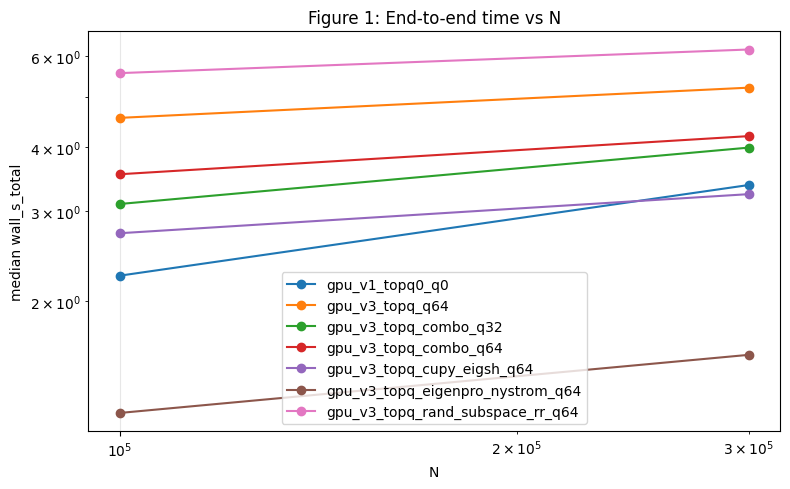

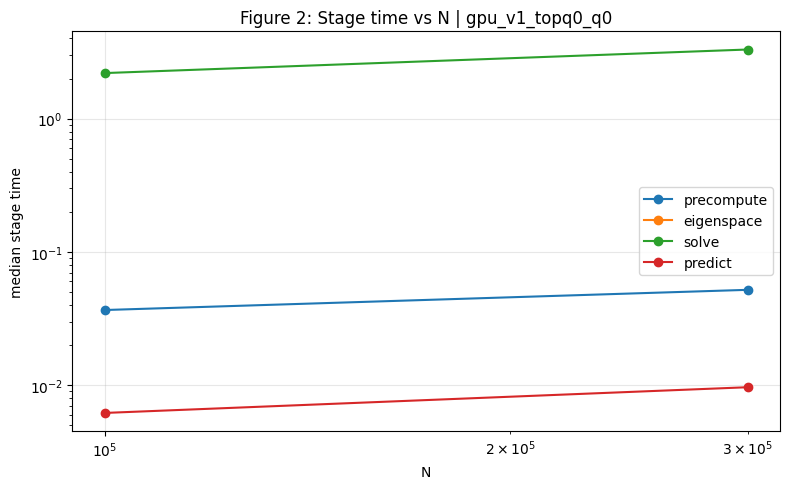

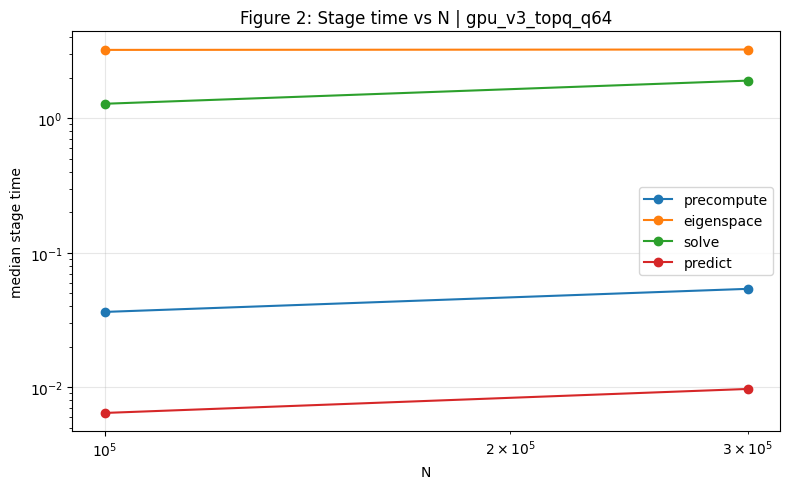

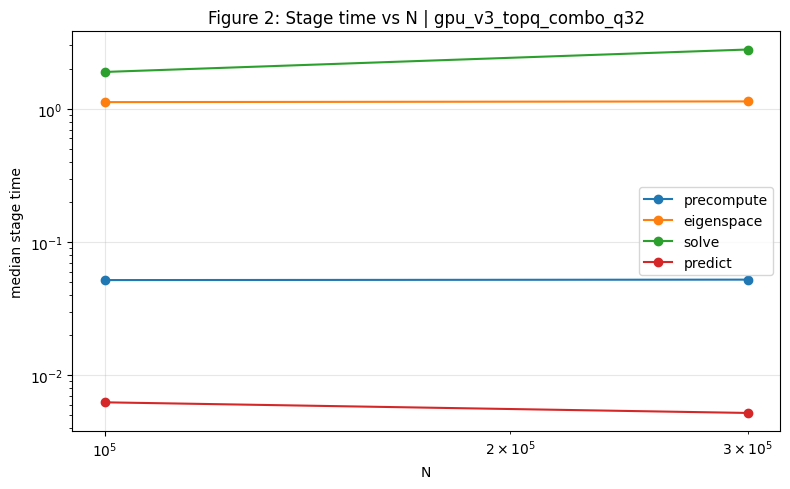

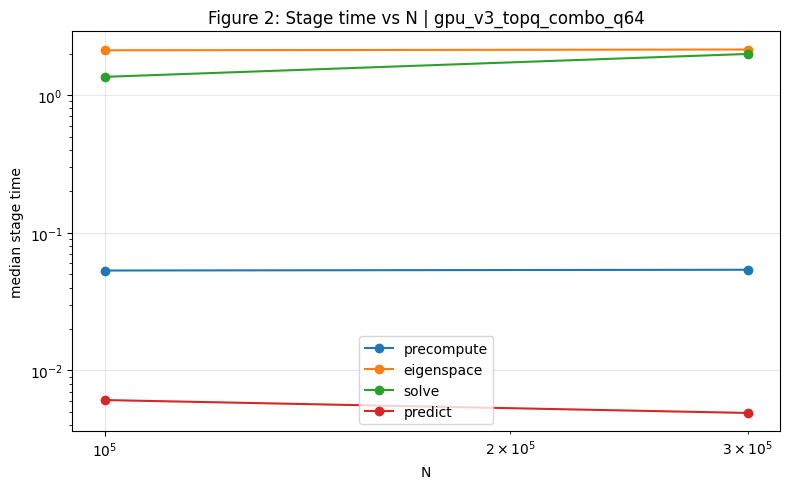

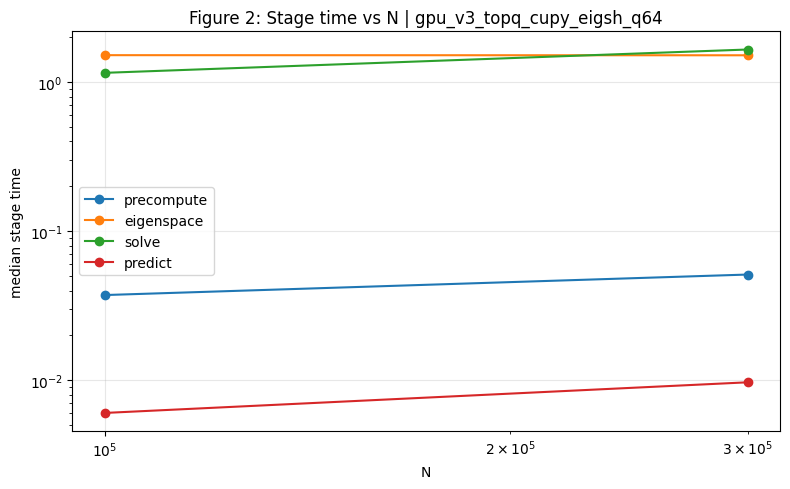

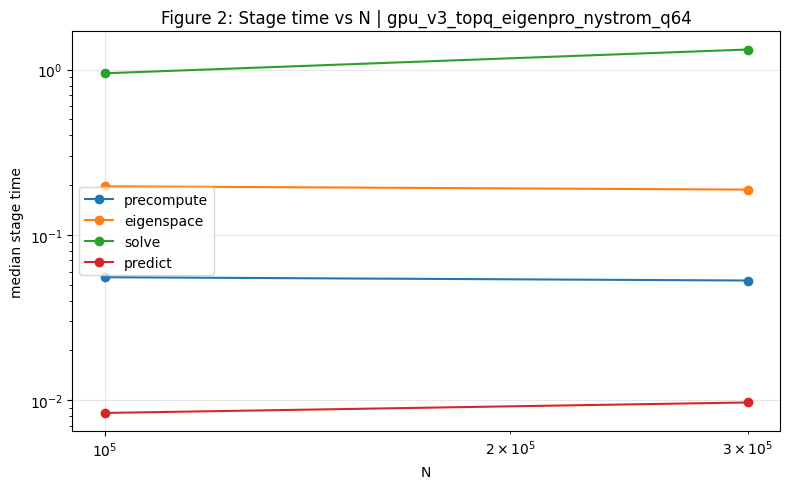

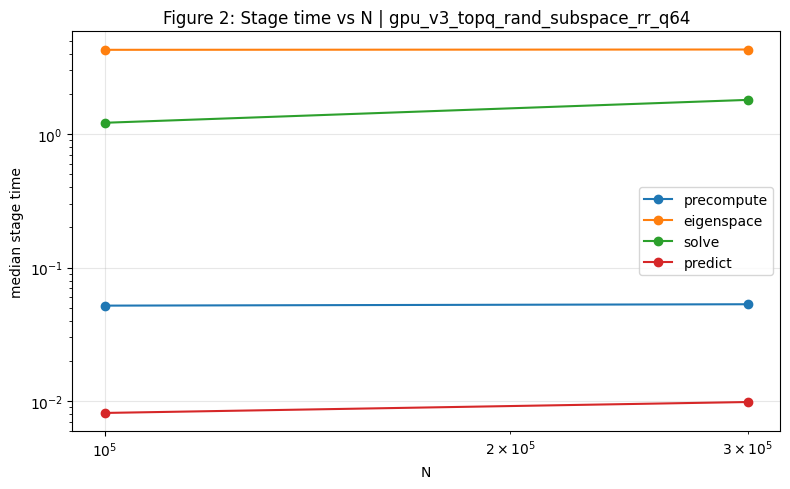

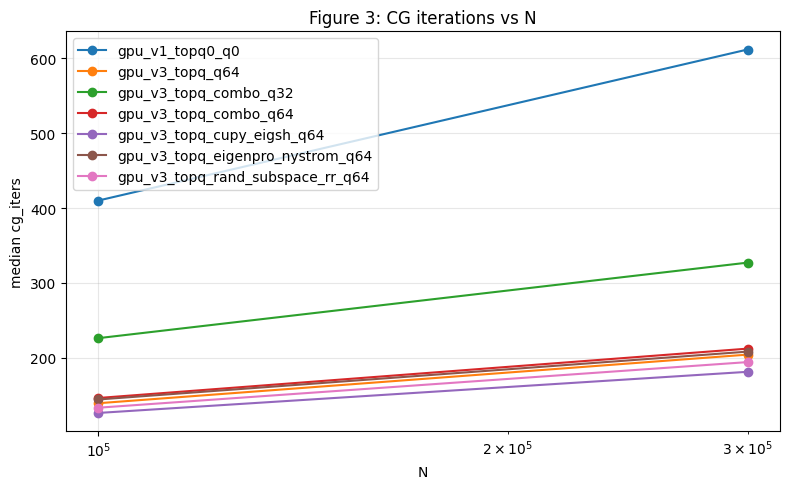

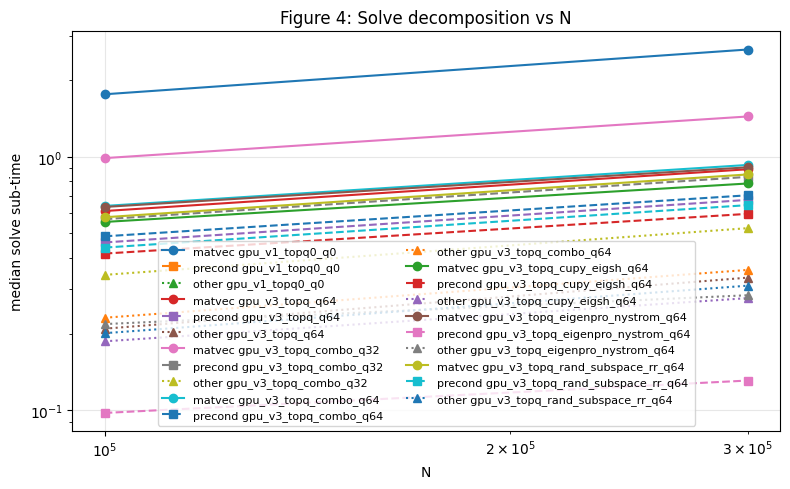

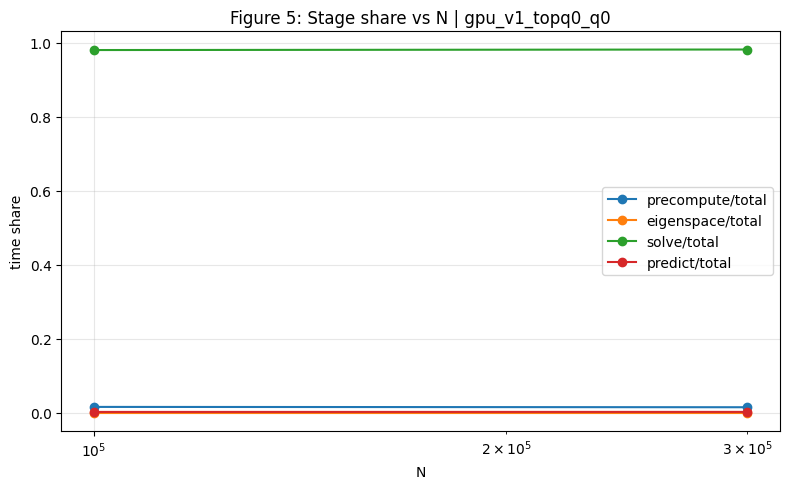

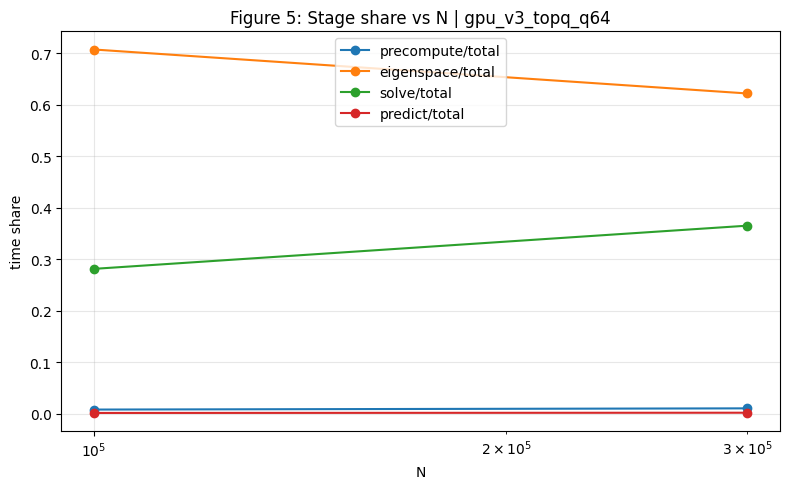

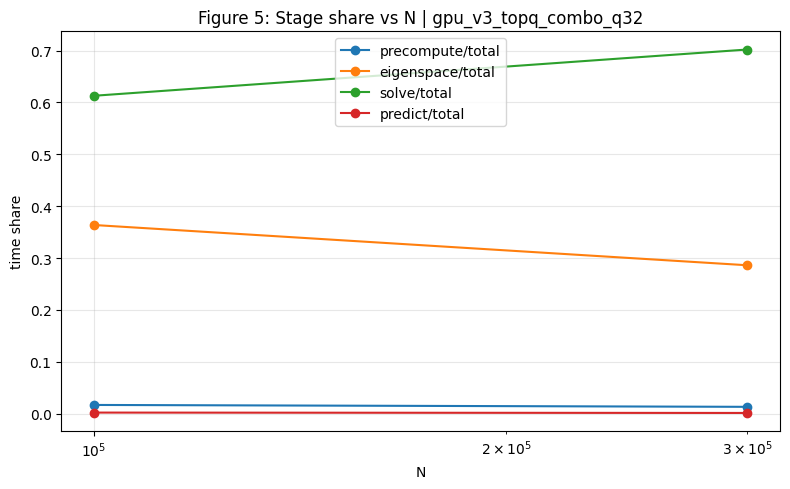

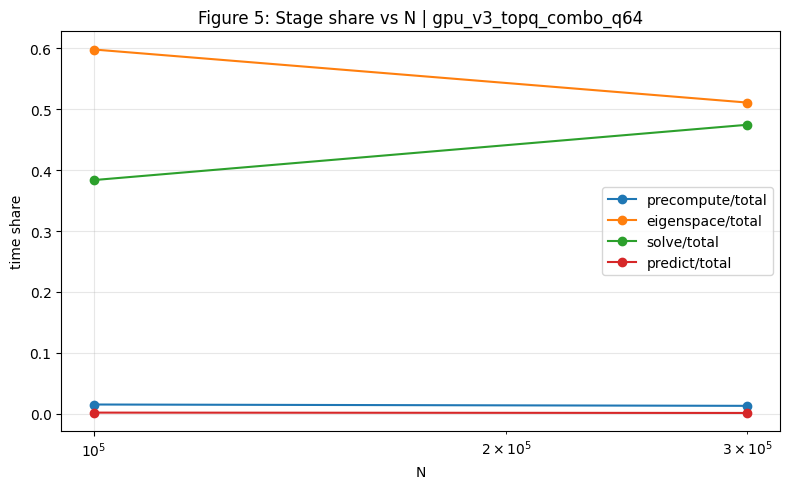

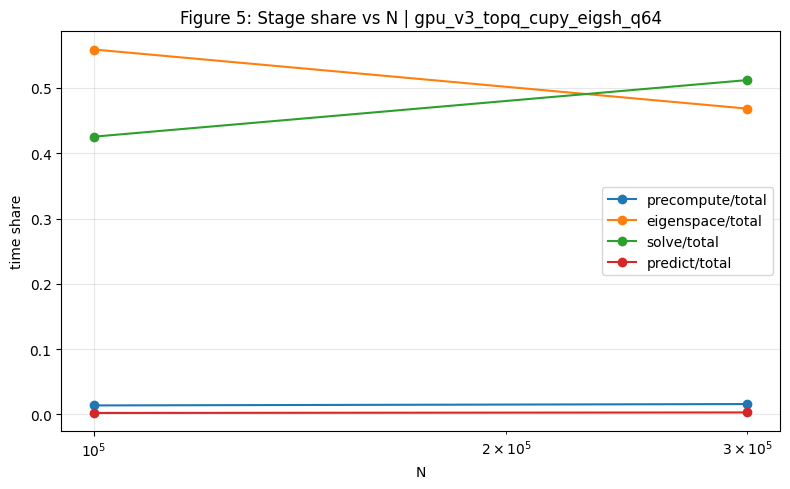

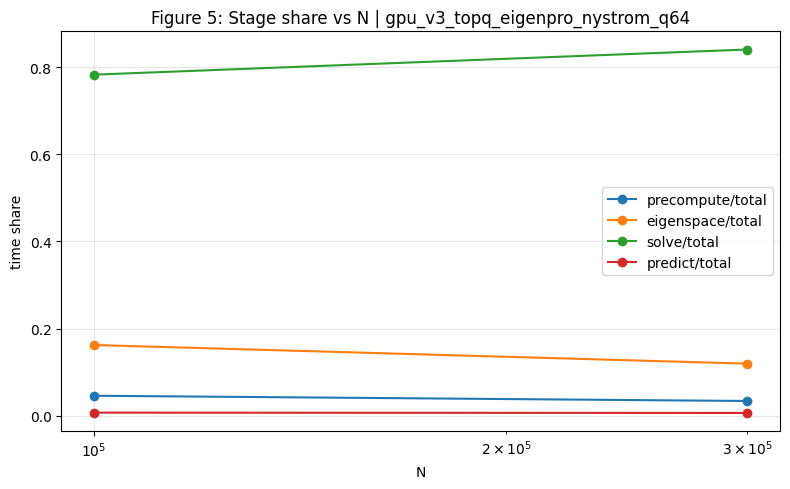

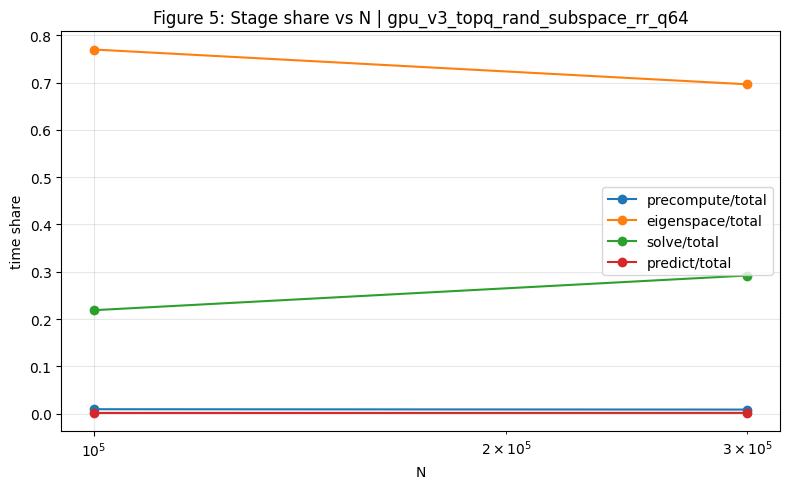

all plots saved in: outputs\weak_gpu_complexity_20260427_010610\plots
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig1_total_time_vs_n_loglog.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v1_topq0_q0.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_q64.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_combo_q32.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_combo_q64.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_cupy_eigsh_q64.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_eigenpro_nystrom_q64.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig2_stage_vs_n_gpu_v3_topq_rand_subspace_rr_q64.png
saved: outputs\weak_gpu_complexity_20260427_010610\plots\fig3_cg_iters_vs_n.png
saved: outputs\weak_gpu_complexity_20260427_010610\pl

In [18]:
from efgp_eigenpro_py.gpu.benchmark_plots import save_complexity_benchmark_plots

plot_dir = OUT_DIR / "plots"
saved_paths = save_complexity_benchmark_plots(
    summary_df,
    plot_dir,
    dpi=180,
    show=True,
)
print("all plots saved in:", plot_dir)
for p in saved_paths:
    print("saved:", p)


In [19]:
def _get_curve(df, mode, top_q):
    s = df[(df["mode"] == mode) & (df["top_q"] == top_q)].sort_values("N").copy()
    return s


v1 = _get_curve(summary_df, "gpu_v1_topq0", 0)
v3_qs = sorted([int(v) for v in summary_df.loc[summary_df["mode"] == "gpu_v3_topq", "top_q"].dropna().unique()])

print("=" * 80)
print("Q1: gpu_v1_topq0 的总时间随 N 如何增长")
if len(v1) >= 2:
    print(v1[["N", "wall_s_total_median", "local_alpha"]])
    print("Q1 observation: local_alpha 趋势见上表，可直接读 log-log 局部斜率。")
else:
    print("Q1 data insufficient")

print("=" * 80)
print("Q2: gpu_v3_topq 相对 gpu_v1_topq0 的快慢和拐点")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    m["v3_faster"] = m["speedup_v1_over_v3"] > 1.0
    print(f"top_q={q}")
    print(m[["N", "wall_s_total_median_v1", "wall_s_total_median_v3", "speedup_v1_over_v3", "v3_faster"]])

print("=" * 80)
print("Q3: 时间增长主要来自哪一段")
for (mode, top_q), g in summary_df.groupby(["mode", "top_q"]):
    g = g.sort_values("N").copy()
    for c in ["time_precompute_median", "time_eigenspace_median", "time_solve_median", "time_predict_median"]:
        g[f"ratio_{c}"] = g[c] / g["wall_s_total_median"].replace(0, np.nan)
    print(f"mode={mode}, top_q={int(top_q)}")
    print(g[["N", "ratio_time_precompute_median", "ratio_time_eigenspace_median", "ratio_time_solve_median", "ratio_time_predict_median"]])

print("=" * 80)
print("Q4: top_q>0 优势扩大还是缩小")
for q in v3_qs:
    v3 = _get_curve(summary_df, "gpu_v3_topq", q)
    m = v1.merge(v3, on=["N", "eps"], suffixes=("_v1", "_v3"))
    if m.empty:
        continue
    m["speedup_v1_over_v3"] = m["wall_s_total_median_v1"] / m["wall_s_total_median_v3"]
    print(f"top_q={q}, speedup trend")
    print(m[["N", "speedup_v1_over_v3"]])

print("=" * 80)
print("Artifacts")
print("raw csv:", RAW_CSV)
print("summary csv:", SUMMARY_CSV)
print("plots dir:", plot_dir)
print("env info:", ENV_JSON)


Q1: gpu_v1_topq0 的总时间随 N 如何增长
        N  wall_s_total_median  local_alpha
0  100000             2.244876          NaN
1  300000             3.369092     0.369551
Q1 observation: local_alpha 趋势见上表，可直接读 log-log 局部斜率。
Q2: gpu_v3_topq 相对 gpu_v1_topq0 的快慢和拐点
top_q=64
        N  wall_s_total_median_v1  wall_s_total_median_v3  speedup_v1_over_v3  \
0  100000                2.244876                4.552169            0.493144   
1  300000                3.369092                5.211377            0.646488   

   v3_faster  
0      False  
1      False  
Q3: 时间增长主要来自哪一段
mode=gpu_v1_topq0, top_q=0
        N  ratio_time_precompute_median  ratio_time_eigenspace_median  \
0  100000                      0.016315                           0.0   
1  300000                      0.015413                           0.0   

   ratio_time_solve_median  ratio_time_predict_median  
0                 0.979996                   0.002754  
1                 0.981446                   0.002863  
mode=gpu_v3_topq,

如果你在本地仓库直接运行（例如 `D:/NU/ML`），可以跳过 `## For github import` 单元，直接从导入单元开始执行。

In [20]:
# ---- Selective SLQ spectral diagnostics on cross-selected (mode_spec, N) ----
import re
from dataclasses import asdict, is_dataclass

import importlib
import efgp_eigenpro_py.gpu.slq_diagnostics as slq_diag
import efgp_eigenpro_py.gpu.slq_pcg_spectrum as slq_pcg_spectrum

slq_diag = importlib.reload(slq_diag)
slq_pcg_spectrum = importlib.reload(slq_pcg_spectrum)
build_slq_matvec_for_benchmark_mode = slq_pcg_spectrum.build_slq_matvec_for_benchmark_mode
SLQLanczosConfig = slq_diag.SLQLanczosConfig
run_slq_lanczos_diagnostic = slq_diag.run_slq_lanczos_diagnostic
summarize_slq_diagnostics = slq_diag.summarize_slq_diagnostics
save_slq_plots = slq_diag.save_slq_plots

# 1) Select experiment types (leave empty to use all MODE_SPECS)
# SLQ 不包含 gpu_v3_topq_eigenpro_nystrom（见下自动过滤）
SLQ_SELECTED_MODE_SPECS = [
    {"mode": "gpu_v1_topq0", "top_q": 0},
    {"mode": "gpu_v3_topq", "top_q": 64}
]

# 2) Select N values (leave empty to use all N_LIST)
SLQ_SELECTED_N_LIST = [100_000]

# 3) SLQ controls
SLQ_CFG = SLQLanczosConfig(
    nv=32,
    k_max=400,
    hermitian_type="complex",
    seed=0,
    breakdown_abs_tol=1e-14,
    breakdown_rel_tol=1e-12,
    reorth_mode="none",
    reorth_window=8,
    reorth_passes=2,
    sync_timing=True,
)
SLQ_SUMMARY_MODE = "spd"  # "spd" or "hermitian"
SLQ_PREFIX_STEPS = list(range(20, SLQ_CFG.k_max + 1, 20))
SLQ_SEED_BASE = 99173

SLQ_DIR = OUT_DIR / "slq_diagnostics"
SLQ_DIR.mkdir(parents=True, exist_ok=True)


def _sanitize_tag(s: str) -> str:
    return re.sub(r"[^0-9a-zA-Z_\-]+", "_", str(s)).strip("_")


def _spec_key(spec: dict) -> tuple[str, int, str]:
    mode = str(spec.get("mode", ""))
    top_q = int(spec.get("top_q", -1))
    combo_cfg = spec.get("combo_cfg", None)
    combo_name = ""
    if isinstance(combo_cfg, dict):
        combo_name = str(combo_cfg.get("name", ""))
    return (mode, top_q, combo_name)


def _to_jsonable(obj):
    if is_dataclass(obj):
        return _to_jsonable(asdict(obj))
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    return obj


def _pick_mode_specs(all_specs: list[dict], selected_specs: list[dict]) -> list[dict]:
    if len(selected_specs) == 0:
        return list(all_specs)

    # Keep explicit user selection even when (mode, top_q, combo) is not in MODE_SPECS
    # (e.g. SLQ-only probes like q=180/360).
    out = []
    seen = set()

    def _push(spec: dict):
        k = _spec_key(spec)
        if k in seen:
            return
        out.append(spec)
        seen.add(k)

    all_by_key = {_spec_key(s): s for s in all_specs}
    for s in selected_specs:
        k = _spec_key(s)
        if k in all_by_key:
            _push(all_by_key[k])
        else:
            _push(dict(s))
    return out


def _pick_n_list(all_n: list[int], selected_n: list[int]) -> list[int]:
    if len(selected_n) == 0:
        return [int(v) for v in all_n]
    selected_set = {int(v) for v in selected_n}
    return [int(v) for v in all_n if int(v) in selected_set]


def _q_lookup(q_map: dict, q: float) -> float:
    if not isinstance(q_map, dict):
        return float("nan")
    if q in q_map:
        return float(q_map[q])
    key = str(q)
    if key in q_map:
        return float(q_map[key])
    for k, v in q_map.items():
        try:
            if abs(float(k) - float(q)) < 1e-15:
                return float(v)
        except Exception:
            pass
    return float("nan")


def _normalize_summary_schema(summary: dict) -> tuple[dict, dict, dict]:
    """
    Support both old schema {config, run_diagnostics, prefix, final}
    and new schema {raw, derived, views}.
    """
    if isinstance(summary, dict) and all(k in summary for k in ("raw", "derived", "views")):
        return summary.get("raw", {}), summary.get("derived", {}), summary.get("views", {})

    if not isinstance(summary, dict):
        return {}, {}, {}

    final = summary.get("final", {}) if isinstance(summary.get("final", {}), dict) else {}
    prefix = summary.get("prefix", []) if isinstance(summary.get("prefix", []), list) else []
    q_map = final.get("quantiles", {}) if isinstance(final.get("quantiles", {}), dict) else {}

    raw_part = {
        "config": summary.get("config", {}),
        "run_diagnostics": summary.get("run_diagnostics", {}),
        "x_grid": np.asarray(final.get("grid", {}).get("x", []), dtype=float),
        "cdf": np.asarray(final.get("grid", {}).get("cdf", []), dtype=float),
        "density": final.get("grid", {}).get("density", {}),
        "extremal_ritz_cloud": final.get("extremal_ritz_cloud", {}),
    }

    q01 = _q_lookup(q_map, 0.01)
    q05 = _q_lookup(q_map, 0.05)
    q95 = _q_lookup(q_map, 0.95)
    q99 = _q_lookup(q_map, 0.99)
    q999 = _q_lookup(q_map, 0.999)
    bw_ratio = float((q95 - q05) / max(abs(_q_lookup(q_map, 0.5)), 1e-30)) if np.isfinite(q95) and np.isfinite(q05) else float("nan")
    tail_ratio = float((q999 - q99) / max(q99 - q01, 1e-30)) if np.isfinite(q999) and np.isfinite(q99) and np.isfinite(q01) else float("nan")
    spike_ratio = float(final.get("lambda_hat_max", np.nan) / max(q999, 1e-30)) if np.isfinite(q999) else float("nan")

    derived_part = {
        "prefix": prefix,
        "final_quantiles": q_map,
        "lambda_hat_min": float(final.get("lambda_hat_min", np.nan)),
        "lambda_hat_max": float(final.get("lambda_hat_max", np.nan)),
        "final_kappa_eff": final.get("kappa_eff", {}),
        "final_spread_eff": final.get("spread_eff", {}),
        "final_near_zero_mass": final.get("near_zero_mass", {}),
        "final_tail_ratios": {
            "bulk_width_ratio": bw_ratio,
            "tail_ratio": tail_ratio,
            "spike_ratio": spike_ratio,
        },
    }

    views_part = {
        "headline": {
            "health": "legacy",
            "dominant_issue": "",
        }
    }
    return raw_part, derived_part, views_part


def _save_slq_plots(case_dir: Path, raw_part: dict, derived_part: dict):
    plot_dir = case_dir / "plots"
    plot_dir.mkdir(parents=True, exist_ok=True)

    # Plotting is centralized in slq_diagnostics.py; notebook only prepares payload.
    _summary_pack = {
        "raw": raw_part if isinstance(raw_part, dict) else {},
        "derived": derived_part if isinstance(derived_part, dict) else {},
        "views": {},
    }
    save_slq_plots(_summary_pack, str(plot_dir), dpi=160)
    return


def _build_slq_matvec_and_size(
    x_train: np.ndarray, y_train: np.ndarray, spec: dict
) -> tuple:
    # SLQ 使用的 matvec 与对应 benchmark 模式一致: v1 为 A, v3 / combo 为 P(A v) 与 PCG 相同
    mode = str(spec.get("mode", ""))
    top_q = int(spec.get("top_q", 0))
    combo = spec.get("combo_cfg", None)
    if combo is not None and not isinstance(combo, dict):
        combo = None
    solver = EFGPSolver(
        kernel=kernel,
        reg_lambda=REG_LAMBDA,
        eps=EPS,
        nufft_tol=1e-10,
        l2scaled=L2_SCALED,
    )
    cfg = GPURunConfig(
        reg_lambda=REG_LAMBDA,
        tol=SOLVE_TOL,
        maxiter=GPU_MAXITER,
        chunk_size=None,
        debug_finite_checks=False,
        backend=BackendConfig(nufft=GPU_NUFFT),
    )
    return build_slq_matvec_for_benchmark_mode(
        mode,
        solver,
        x_train,
        y_train,
        cfg,
        top_q=top_q,
        combo_cfg=combo,
        v3_oversample=V3_OVERSAMPLE,
        v3_n_iter=V3_N_ITER,
        dim=int(DIM),
    )


picked_specs = _pick_mode_specs(MODE_SPECS, SLQ_SELECTED_MODE_SPECS)
picked_specs = [
    s
    for s in picked_specs
    if str(s.get("mode", "")) != "gpu_v3_topq_eigenpro_nystrom"
]
picked_n = _pick_n_list(N_LIST, SLQ_SELECTED_N_LIST)

print("SLQ selected mode specs:")
for s in picked_specs:
    print("  ", s)
print("SLQ selected N list:", picked_n)

if len(picked_specs) == 0:
    raise ValueError(
        "No SLQ mode left: SLQ ignores gpu_v3_topq_eigenpro_nystrom; add other modes to "
        "SLQ_SELECTED_MODE_SPECS or MODE_SPECS."
    )
if len(picked_n) == 0:
    raise ValueError("No N selected for SLQ. Check SLQ_SELECTED_N_LIST.")

slq_rows = []
case_idx = 0
for n_train in picked_n:
    for spec in picked_specs:
        case_idx += 1
        mode = str(spec.get("mode", ""))
        top_q = int(spec.get("top_q", 0))
        combo_name = ""
        if isinstance(spec.get("combo_cfg", None), dict):
            combo_name = str(spec["combo_cfg"].get("name", ""))

        case_seed = int(SLQ_SEED_BASE + case_idx)
        print("=" * 100)
        print(f"[SLQ] start N={n_train}, mode={mode}, top_q={top_q}, combo={combo_name}, seed={case_seed}")

        x_train, y_train = make_dataset(DIM, int(n_train), true_func_2d, noise=NOISE, seed=case_seed)
        backend, matvec, size, slq_op_meta = _build_slq_matvec_and_size(x_train, y_train, spec)

        _spec_mode = (
            str(slq_op_meta.get("slq_spectrum", "")) if isinstance(slq_op_meta, dict) else ""
        )
        _spectrum_mode = (
            "hermitian" if _spec_mode == "M_inv_A" else SLQ_SUMMARY_MODE
        )

        t0 = time.perf_counter()
        slq_res = run_slq_lanczos_diagnostic(
            backend=backend,
            matvec=matvec,
            size=size,
            cfg=SLQ_CFG,
        )
        summary = summarize_slq_diagnostics(
            slq_res,
            prefix_steps=SLQ_PREFIX_STEPS,
            spectrum_mode=_spectrum_mode,
        )
        if isinstance(summary, dict) and isinstance(summary.get("raw"), dict) and isinstance(
            slq_op_meta, dict
        ):
            summary["raw"]["slq_operator_meta"] = _to_jsonable(slq_op_meta)
        t1 = time.perf_counter()

        raw_part, derived_part, views_part = _normalize_summary_schema(summary)

        lam_min = float(derived_part.get("lambda_hat_min", np.nan))
        lam_max = float(derived_part.get("lambda_hat_max", np.nan))
        q_map = derived_part.get("final_quantiles", {}) if isinstance(derived_part, dict) else {}
        q01 = _q_lookup(q_map, 0.01)
        q99 = _q_lookup(q_map, 0.99)

        mode_tag = _sanitize_tag(mode)
        combo_tag = _sanitize_tag(combo_name) if combo_name else "none"
        case_tag = f"N{int(n_train)}_{mode_tag}_q{int(top_q)}_combo_{combo_tag}_seed{case_seed}"
        case_dir = SLQ_DIR / case_tag
        case_dir.mkdir(parents=True, exist_ok=True)

        np.savez_compressed(
            case_dir / "lanczos_coeffs.npz",
            alpha=slq_res.alpha,
            beta=slq_res.beta,
            active_steps=slq_res.active_steps,
        )

        (case_dir / "slq_summary.json").write_text(
            json.dumps(_to_jsonable(summary), indent=2),
            encoding="utf-8",
        )

        x_grid = np.asarray(raw_part.get("x_grid", []), dtype=float)
        cdf_grid = np.asarray(raw_part.get("cdf", []), dtype=float)
        density_dict = raw_part.get("density", {}) if isinstance(raw_part, dict) else {}
        grid_df = pd.DataFrame({"x": x_grid, "cdf": cdf_grid})
        if isinstance(density_dict, dict):
            for fac, den in density_dict.items():
                col = f"density_sigmafac_{fac}"
                grid_df[col] = np.asarray(den, dtype=float)
        grid_df.to_csv(case_dir / "slq_grid.csv", index=False)

        _save_slq_plots(case_dir, raw_part, derived_part)

        row = {
            "case_tag": case_tag,
            "N": int(n_train),
            "mode": mode,
            "top_q": int(top_q),
            "combo_name": combo_name,
            "slq_operator": (
                str(slq_op_meta.get("slq_spectrum", ""))
                if isinstance(slq_op_meta, dict)
                else ""
            ),
            "seed": int(case_seed),
            "size": int(size),
            "wall_s": float(t1 - t0),
            "lambda_hat_min": lam_min,
            "lambda_hat_max": lam_max,
            "q01": q01,
            "q99": q99,
            "m_final": int(derived_part.get("prefix", [])[-1].get("m", SLQ_CFG.k_max)) if (isinstance(derived_part, dict) and len(derived_part.get("prefix", [])) > 0) else int(SLQ_CFG.k_max),
            "health": str(views_part.get("headline", {}).get("health", "")) if isinstance(views_part, dict) else "",
            "dominant_issue": str(views_part.get("headline", {}).get("dominant_issue", "")) if isinstance(views_part, dict) else "",
            "out_dir": str(case_dir),
        }
        slq_rows.append(row)

        print(f"[SLQ] done case={case_tag}")
        print(f"      lambda_hat_min={lam_min:.6e}, lambda_hat_max={lam_max:.6e}, q01={q01:.6e}, q99={q99:.6e}")
        print(f"      health={row['health']}, dominant_issue={row['dominant_issue']}")
        print(f"      saved: {case_dir}")
        if not (np.isfinite(lam_min) and np.isfinite(lam_max) and np.isfinite(q01) and np.isfinite(q99)):
            print("      warning: NaN detected in compact metrics, check slq_summary.json and schema normalization.")

slq_df = pd.DataFrame(slq_rows)
slq_csv = SLQ_DIR / "slq_cases_summary.csv"
slq_df.to_csv(slq_csv, index=False)
print("=" * 100)
print("SLQ cross-selected diagnostics finished.")
print("summary csv:", slq_csv)
print(slq_df)


SLQ selected mode specs:
   {'mode': 'gpu_v1_topq0', 'top_q': 0}
   {'mode': 'gpu_v3_topq', 'top_q': 64}
SLQ selected N list: [100000]
[SLQ] start N=100000, mode=gpu_v1_topq0, top_q=0, combo=, seed=99174
[SLQ] done case=N100000_gpu_v1_topq0_q0_combo_none_seed99174
      lambda_hat_min=1.002149e-01, lambda_hat_max=5.551331e+03, q01=1.002149e-01, q99=3.923230e-01
      health=caution, dominant_issue=upper_spikes
      saved: outputs\weak_gpu_complexity_20260427_010610\slq_diagnostics\N100000_gpu_v1_topq0_q0_combo_none_seed99174
[SLQ] start N=100000, mode=gpu_v3_topq, top_q=64, combo=, seed=99175
[SLQ] done case=N100000_gpu_v3_topq_q64_combo_none_seed99175
      lambda_hat_min=-1.637290e-01, lambda_hat_max=3.286966e+02, q01=9.849424e-02, q99=3.826023e-01
      health=stable, dominant_issue=upper_spikes
      saved: outputs\weak_gpu_complexity_20260427_010610\slq_diagnostics\N100000_gpu_v3_topq_q64_combo_none_seed99175
SLQ cross-selected diagnostics finished.
summary csv: outputs\weak_gpu_

In [21]:
import os
import time
from datetime import timedelta
from google.colab import files, runtime

# --- 1. 结束计时 ---
end_time = time.time()
try:
    # 确保你在最开头运行了 start_time = time.time()
    elapsed_total = end_time - start_time
    time_str = str(timedelta(seconds=int(elapsed_total)))
except NameError:
    time_str = "未知（未检测到 start_time）"

# --- 2. 配置路径 ---
local_folder = 'outputs' # 你的本地输出文件夹
zip_name = 'experiment_results_20260424.zip'
# 使用开头挂载好的 DRIVE_OUTPUT_DIR
target_drive_path = os.path.join(DRIVE_OUTPUT_DIR, zip_name)

# --- 3. 核心执行逻辑 ---
if os.path.exists(local_folder):
    print(f"📦 正在打包 {local_folder} ...")
    !zip -r -q {zip_name} {local_folder}
    
    # A. 先通过 Linux 命令强制同步到已挂载的 Drive (这是阻塞操作，最安全)
    print(f"💾 正在同步压缩包到 Google Drive...")
    !cp {zip_name} "{target_drive_path}"
    
    # B. 检测 Drive 文件是否存在（非手动检测）
    if os.path.exists(target_drive_path):
        print("✅ 检测到 Drive 同步成功！数据已安全。")
        
        # C. 触发浏览器下载备份
        print("📥 启动浏览器备份下载...")
        files.download(zip_name)
        
        # 打印本次实验信息
        print("-" * 30)
        print(f"📊 实验状态: 成功完成并备份")
        print(f"⏱️ 累计运行耗时: {time_str}")
        print("-" * 30)
        
        # 留出 20 秒给浏览器响应下载请求（哪怕失败，Drive 里也已经有了）
        print("等待 20 秒后将自动断开 GPU 以节省点数...")
        time.sleep(20)
        
        # D. 主动断开
        runtime.unassign()
    else:
        print("❌ 警告：同步到 Drive 失败，为了防止数据丢失，已取消自动断开。请手动检查！")
else:
    print(f"❌ 错误：未找到文件夹 {local_folder}，请检查路径。")

ModuleNotFoundError: No module named 'google.colab'